In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [ ]:
GITHUB_BASE_URL = 'https://github.com/theomniscient-omnipotentrat/DBA-Final-Assignment/tree/6d8b5a6f7e762e4d73bea18d7e24622f75441726/northstar_dataset'

In [ ]:

files_to_load = {
    'app_events': 'app_events.csv',
    'complaints': 'complaints.csv',
    'customers': 'customers.csv',
    'data_dictionary': 'data_dictionary.csv',
    'deliveries': 'deliveries.csv',
    'drivers': 'drivers.csv',
    'hubs': 'hubs.csv',
    'incidents': 'incidents.csv',
    'orders': 'orders.csv',
    'vehicles': 'vehicles.csv'
}

data = {}

for name, filename in files_to_load.items():
    file_url = f'{GITHUB_BASE_URL}/{filename}'
    data[name] = pd.read_csv(file_url)
    print(f'{name}: {data[name].shape[0]} rows, {data[name].shape[1]} columns loaded from GitHub')

# Create individual dataframe names so the rest of the notebook can use clear variable names.
app_events = data['app_events']
complaints = data['complaints']
customers = data['customers']
data_dict = data['data_dictionary']
deliveries = data['deliveries']
drivers = data['drivers']
hubs = data['hubs']
incidents = data['incidents']
orders = data['orders']
vehicles = data['vehicles']

# Keep one dictionary of all files for repeated inspection loops.
all_dfs = {
    'app_events': app_events,
    'complaints': complaints,
    'customers': customers,
    'data_dict': data_dict,
    'deliveries': deliveries,
    'drivers': drivers,
    'hubs': hubs,
    'incidents': incidents,
    'orders': orders,
    'vehicles': vehicles
}

print("All datasets loaded.\n")
for name, df in all_dfs.items():
    print(f"  {name:<15} → {df.shape[0]:>5} rows × {df.shape[1]} cols")

app_events: 640 rows, 10 columns loaded from GitHub
complaints: 320 rows, 10 columns loaded from GitHub
customers: 650 rows, 9 columns loaded from GitHub
data_dictionary: 9 rows, 3 columns loaded from GitHub
deliveries: 950 rows, 13 columns loaded from GitHub
drivers: 170 rows, 8 columns loaded from GitHub
hubs: 8 rows, 5 columns loaded from GitHub
incidents: 280 rows, 7 columns loaded from GitHub
orders: 1250 rows, 11 columns loaded from GitHub
vehicles: 120 rows, 8 columns loaded from GitHub
All datasets loaded.

  app_events      →   640 rows × 10 cols
  complaints      →   320 rows × 10 cols
  customers       →   650 rows × 9 cols
  data_dict       →     9 rows × 3 cols
  deliveries      →   950 rows × 13 cols
  drivers         →   170 rows × 8 cols
  hubs            →     8 rows × 5 cols
  incidents       →   280 rows × 7 cols
  orders          →  1250 rows × 11 cols
  vehicles        →   120 rows × 8 cols


In [ ]:
for name, df in all_dfs.items():
    print(f"\n{'─'*50}")
    print(f"  TABLE: {name.upper()}")
    print(f"{'─'*50}")
    print(df.dtypes.to_string())
    print(f"\nFirst 3 rows:")
    print(df.head(3).to_string(index=False))


──────────────────────────────────────────────────
  TABLE: APP_EVENTS
──────────────────────────────────────────────────
event_id           object
customer_id        object
order_id           object
event_timestamp    object
event_type         object
session_id         object
device_type        object
zone_context       object
api_latency_ms      int64
success_flag        int64

First 3 rows:
event_id customer_id order_id     event_timestamp   event_type session_id device_type zone_context  api_latency_ms  success_flag
 AE00001       C0488      NaN 2024-08-09 03:25:00  eta_refresh     S19847     Android        north             301             1
 AE00002       C0595   O00950 2024-02-13 22:29:00 search_route     S32766     Android        SOUTH              60             1
 AE00003       C0494   O00170 2025-08-11 09:29:00  chat_opened     S99516         iOS      Airport            1118             1

──────────────────────────────────────────────────
  TABLE: COMPLAINTS
──────────────

In [ ]:
missing_summary = []

for name, df in all_dfs.items():
    for col in df.columns:
        nulls = df[col].isnull().sum()
        if nulls > 0:
            pct = round(nulls / len(df) * 100, 2)
            missing_summary.append({
                "Table":   name,
                "Column":  col,
                "Missing": nulls,
                "Pct (%)": pct
            })

missing_df = pd.DataFrame(missing_summary)
print(missing_df.to_string(index=False))


     Table                        Column  Missing  Pct (%)
app_events                      order_id      144    22.50
complaints           compensation_amount       16     5.00
 customers                 loyalty_score       20     3.08
 customers             preferred_channel       13     2.00
deliveries         delivery_completed_at       19     2.00
deliveries customer_rating_post_delivery       14     1.47
   drivers                training_score        7     4.12
 incidents                resolved_hours       17     6.07
    orders               booking_channel       25     2.00
  vehicles            battery_health_pct        4     3.33


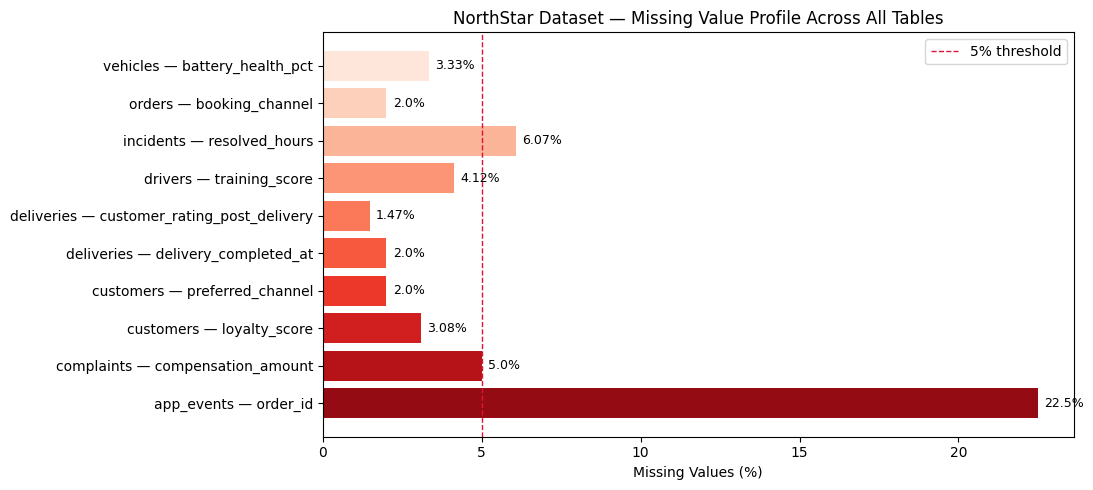

Figure saved: fig1_missing_values.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette("Reds_r", len(missing_df))
bars = ax.barh(
    missing_df["Table"] + " — " + missing_df["Column"],
    missing_df["Pct (%)"],
    color=colors
)
ax.set_xlabel("Missing Values (%)")
ax.set_title("NorthStar Dataset — Missing Value Profile Across All Tables")
ax.axvline(5, color="crimson", linestyle="--", linewidth=1, label="5% threshold")
ax.legend()
for bar, val in zip(bars, missing_df["Pct (%)"]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("fig1_missing_values.png", bbox_inches="tight")
plt.show()
print("Figure saved: fig1_missing_values.png")

In [ ]:
ZONE_MAP = {
    # North variants
    "north": "North", "NORTH": "North",
    # Airport variants
    "airport": "Airport", "AIRPORT": "Airport",
    # Central variants
    "central": "Central", "CENTRAL": "Central", "Ctr": "Central",
    # East variants
    "east": "East", "EAST": "East",
    # West variants
    "west": "West", "WEST": "West",
    # South variants
    "south": "South", "SOUTH": "South",
    # Riverside variants
    "riverside": "Riverside", "RiverSide": "Riverside", "RIVERSIDE": "Riverside",
}

ZONE_COLUMNS = {
    "customers":  ["home_zone"],
    "orders":     ["pickup_zone", "dropoff_zone"],
    "drivers":    ["base_zone"],
    "vehicles":   ["assigned_zone"],
    "app_events": ["zone_context"],
    "hubs":       ["zone"],
}

for table_name, cols in ZONE_COLUMNS.items():
    df = all_dfs[table_name]
    for col in cols:
        before = df[col].unique()
        df[col] = df[col].map(lambda x: ZONE_MAP.get(x, x) if pd.notna(x) else x)
        after = df[col].unique()
        print(f"  {table_name}.{col} — {len(before)} variants → {len(after)} canonical values")

unique_sorted_zones = sorted(set(ZONE_MAP.values()))

print("\nVerification — customers.home_zone unique values after cleaning:")
print(sorted(customers["home_zone"].dropna().unique()))

  customers.home_zone — 16 variants → 7 canonical values
  orders.pickup_zone — 16 variants → 7 canonical values
  orders.dropoff_zone — 16 variants → 7 canonical values
  drivers.base_zone — 16 variants → 7 canonical values
  vehicles.assigned_zone — 16 variants → 7 canonical values
  app_events.zone_context — 16 variants → 7 canonical values
  hubs.zone — 7 variants → 7 canonical values

Verification — customers.home_zone unique values after cleaning:
['Airport', 'Central', 'East', 'North', 'Riverside', 'South', 'West']


In [ ]:
# --- customers ---
# loyalty_score: continuous metric → median imputation (robust to skew)
median_loyalty = customers["loyalty_score"].median()
customers["loyalty_score"].fillna(median_loyalty, inplace=True)
print(f"customers.loyalty_score — filled {20} NaNs with median={median_loyalty:.2f}")

# preferred_channel: categorical → mode imputation
mode_channel = customers["preferred_channel"].mode()[0]
customers["preferred_channel"].fillna(mode_channel, inplace=True)
print(f"customers.preferred_channel — filled NaNs with mode='{mode_channel}'")

# --- orders ---
mode_booking = orders["booking_channel"].mode()[0]
orders["booking_channel"].fillna(mode_booking, inplace=True)
print(f"orders.booking_channel — filled NaNs with mode='{mode_booking}'")

# --- deliveries ---
# delivery_completed_at: missing means unresolved → flag, do not impute timestamp
deliveries["completion_missing_flag"] = deliveries["delivery_completed_at"].isnull().astype(int)
print(f"deliveries.delivery_completed_at — {19} NaNs flagged (completion_missing_flag=1)")

# customer_rating_post_delivery: median imputation per delivery_status group
rating_medians = deliveries.groupby("delivery_status")["customer_rating_post_delivery"].median()
print(f"deliveries.customer_rating_post_delivery — imputing by status group medians:\n  {rating_medians.to_dict()}")
deliveries["customer_rating_post_delivery"] = deliveries.groupby("delivery_status")[
    "customer_rating_post_delivery"
].transform(lambda x: x.fillna(x.median()))

customers.loyalty_score — filled 20 NaNs with median=59.60
customers.preferred_channel — filled NaNs with mode='App'
orders.booking_channel — filled NaNs with mode='App'
deliveries.delivery_completed_at — 19 NaNs flagged (completion_missing_flag=1)
deliveries.customer_rating_post_delivery — imputing by status group medians:
  {'Delayed': 3.2, 'Failed': 3.03, 'OnTime': 4.325}


/tmp/ipykernel_12242/2699421702.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customers["loyalty_score"].fillna(median_loyalty, inplace=True)
/tmp/ipykernel_12242/2699421702.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [ ]:
# --- drivers ---
# training_score: median imputation
median_training = drivers["training_score"].median()
drivers["training_score"].fillna(median_training, inplace=True)
print(f"drivers.training_score — filled NaNs with median={median_training:.2f}")

# --- vehicles ---
# battery_health_pct: median per vehicle_type (EVs vs non-EVs have different profiles)
vehicles["battery_health_pct"] = vehicles.groupby("vehicle_type")[
    "battery_health_pct"
].transform(lambda x: x.fillna(x.median()))
print("vehicles.battery_health_pct — filled NaNs with per-type median")

# --- incidents ---
# resolved_hours: median imputation per severity
incidents["resolved_hours"] = incidents.groupby("severity")[
    "resolved_hours"
].transform(lambda x: x.fillna(x.median()))
print("incidents.resolved_hours — filled NaNs with per-severity median")


drivers.training_score — filled NaNs with median=75.20
vehicles.battery_health_pct — filled NaNs with per-type median
incidents.resolved_hours — filled NaNs with per-severity median


/tmp/ipykernel_12242/3249368937.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  drivers["training_score"].fillna(median_training, inplace=True)


In [ ]:
# --- complaints ---
# compensation_amount: median per severity
complaints["compensation_amount"] = complaints.groupby("severity")[
    "compensation_amount"
].transform(lambda x: x.fillna(x.median()))
print("complaints.compensation_amount — filled NaNs with per-severity median")

# --- app_events ---
# order_id missing = unlinked session events (browsing/search without booking)
# Do NOT impute — instead flag them
app_events["is_unlinked_session"] = app_events["order_id"].isnull().astype(int)
print(f"app_events.order_id — {144} NaNs flagged as unlinked sessions (is_unlinked_session=1)")

# ── Final null check ──
print("\n── Post-imputation null check ──")
for name, df in all_dfs.items():
    total_nulls = df.isnull().sum().sum()
    if total_nulls > 0:
        print(f"  ⚠ {name}: {total_nulls} nulls remaining (expected for flagged columns)")
    else:
        print(f"  ✔ {name}: 0 nulls")

complaints.compensation_amount — filled NaNs with per-severity median
app_events.order_id — 144 NaNs flagged as unlinked sessions (is_unlinked_session=1)

── Post-imputation null check ──
  ⚠ app_events: 144 nulls remaining (expected for flagged columns)
  ✔ complaints: 0 nulls
  ✔ customers: 0 nulls
  ✔ data_dict: 0 nulls
  ⚠ deliveries: 19 nulls remaining (expected for flagged columns)
  ✔ drivers: 0 nulls
  ✔ hubs: 0 nulls
  ✔ incidents: 0 nulls
  ✔ orders: 0 nulls
  ✔ vehicles: 0 nulls


Deliveries with completion BEFORE dispatch: 64
delivery_id       dispatch_time      delivery_completed_at  actual_duration_hours delivery_status
    DL00002 2025-01-11 18:45:00 2025-01-11 17:39:00.000000              -1.100000          OnTime
    DL00011 2024-02-02 03:09:00 2024-02-02 02:29:05.367622              -0.665176          OnTime
    DL00018 2025-07-29 10:52:00 2025-07-29 09:54:19.874248              -0.961146          OnTime
    DL00029 2024-05-15 06:49:00 2024-05-15 04:38:00.000000              -2.183333          OnTime
    DL00031 2025-07-23 23:32:00 2025-07-23 23:21:38.152021              -0.172736          OnTime
    DL00047 2024-02-19 04:07:00 2024-02-19 03:46:04.685358              -0.348699          OnTime
    DL00050 2025-09-05 05:03:00 2025-09-05 03:24:00.000000              -1.650000          OnTime
    DL00061 2024-12-06 06:18:00 2024-12-06 05:02:21.529834              -1.260686          OnTime
    DL00065 2024-02-24 01:55:00 2024-02-24 01:52:27.078194             

/tmp/ipykernel_12242/2677203487.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


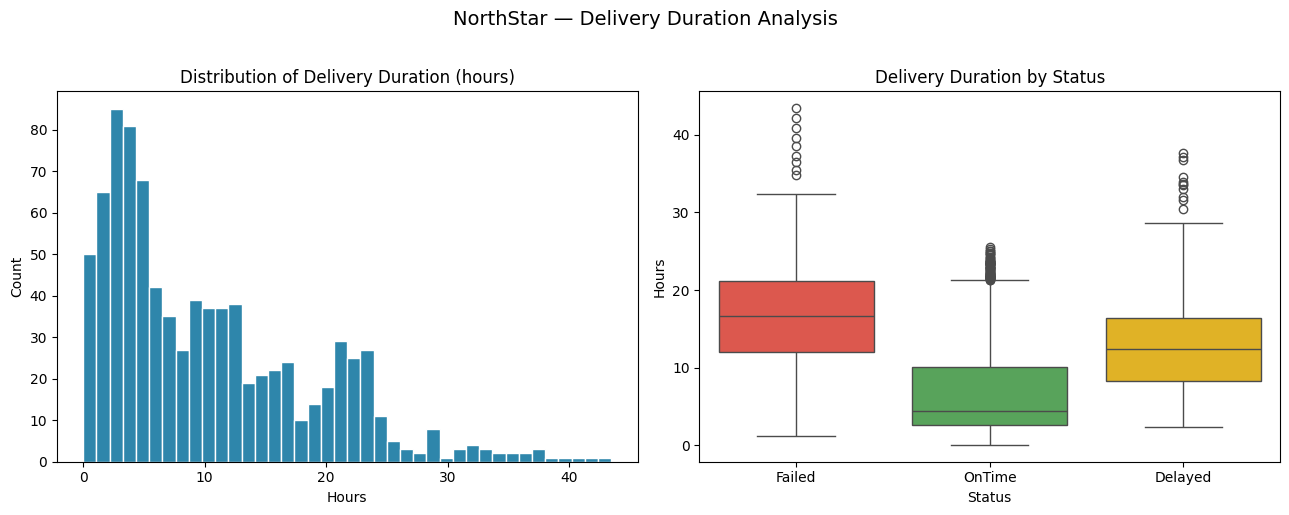

Figure saved: fig2_delivery_duration.png


In [ ]:
deliveries["dispatch_time"] = pd.to_datetime(deliveries["dispatch_time"])
deliveries["delivery_completed_at"] = pd.to_datetime(deliveries["delivery_completed_at"])

# Compute actual delivery duration in hours
deliveries["actual_duration_hours"] = (
    deliveries["delivery_completed_at"] - deliveries["dispatch_time"]
).dt.total_seconds() / 3600

# Flag impossible records: completed BEFORE dispatch
negative_duration = deliveries[deliveries["actual_duration_hours"] < 0]
print(f"Deliveries with completion BEFORE dispatch: {len(negative_duration)}")
print(negative_duration[["delivery_id","dispatch_time","delivery_completed_at",
                          "actual_duration_hours","delivery_status"]].to_string(index=False))

# Flag these for investigation (do not drop — preserve audit trail)
deliveries["temporal_anomaly_flag"] = (deliveries["actual_duration_hours"] < 0).astype(int)
print(f"\ntemporal_anomaly_flag=1 applied to {len(negative_duration)} records.")

# Duration distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clean_dur = deliveries[deliveries["temporal_anomaly_flag"] == 0]["actual_duration_hours"]
axes[0].hist(clean_dur, bins=40, color="#2E86AB", edgecolor="white")
axes[0].set_title("Distribution of Delivery Duration (hours)")
axes[0].set_xlabel("Hours")
axes[0].set_ylabel("Count")

sns.boxplot(
    data=deliveries[deliveries["temporal_anomaly_flag"] == 0],
    x="delivery_status", y="actual_duration_hours",
    palette={"OnTime": "#4CAF50", "Delayed": "#FFC107", "Failed": "#F44336"},
    ax=axes[1]
)
axes[1].set_title("Delivery Duration by Status")
axes[1].set_xlabel("Status")
axes[1].set_ylabel("Hours")

plt.suptitle("NorthStar — Delivery Duration Analysis", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("fig2_delivery_duration.png", bbox_inches="tight")
plt.show()
print("Figure saved: fig2_delivery_duration.png")



In [ ]:
deliveries = deliveries.merge(
    orders[["order_id", "promised_window_hours", "service_type",
            "priority_level", "pickup_zone", "dropoff_zone", "order_value"]],
    on="order_id", how="left"
)

deliveries["delay_hours"] = np.where(
    deliveries["actual_duration_hours"] > deliveries["promised_window_hours"],
    deliveries["actual_duration_hours"] - deliveries["promised_window_hours"],
    0
)
deliveries["is_late"] = (deliveries["delay_hours"] > 0).astype(int)

print("deliveries — new features: delay_hours, is_late")

deliveries — new features: delay_hours, is_late


In [ ]:
drivers["performance_score"] = (
    drivers["training_score"] * 0.4 + drivers["driver_rating"] * 20 * 0.6
).round(2)

# Segment into tiers
drivers["performance_tier"] = pd.cut(
    drivers["performance_score"],
    bins=[0, 50, 70, 85, 100],
    labels=["Low", "Moderate", "High", "Elite"]
)
print("drivers — new features: performance_score, performance_tier")
print(drivers["performance_tier"].value_counts().to_string())


drivers — new features: performance_score, performance_tier
performance_tier
High        123
Elite        34
Moderate     13
Low           0


In [ ]:
vehicles["commission_date"] = pd.to_datetime(vehicles["commission_date"])
reference_date = pd.Timestamp("2026-04-01")
vehicles["age_months"] = (
    (reference_date - vehicles["commission_date"]).dt.days / 30.44
).round(1)

# Risk flag: old vehicle + low battery + active status
vehicles["maintenance_risk_flag"] = (
    (vehicles["battery_health_pct"] < 60) &
    (vehicles["maintenance_status"] == "Active") &
    (vehicles["age_months"] > 12)
).astype(int)

print(f"\nvehicles — maintenance_risk_flag=1: {vehicles['maintenance_risk_flag'].sum()} vehicles")



vehicles — maintenance_risk_flag=1: 4 vehicles


In [ ]:
customers["engagement_segment"] = pd.cut(
    customers["app_engagement_score"],
    bins=[0, 33, 66, 100],
    labels=["Low", "Medium", "High"]
)
print("\ncustomers — engagement_segment distribution:")
print(customers["engagement_segment"].value_counts().to_string())



customers — engagement_segment distribution:
engagement_segment
Medium    353
High      228
Low        69


In [ ]:
orders["is_cross_zone"] = (orders["pickup_zone"] != orders["dropoff_zone"]).astype(int)
print(f"\norders — cross-zone orders: {orders['is_cross_zone'].sum()} / {len(orders)}")



orders — cross-zone orders: 1065 / 1250


In [ ]:
incidents["is_critical_open"] = (
    (incidents["severity"] == "Critical") &
    (incidents["resolution_status"].isin(["Open", "Escalated", "PendingVendor"]))
).astype(int)
print(f"incidents — critical & unresolved: {incidents['is_critical_open'].sum()}")


incidents — critical & unresolved: 13


In [ ]:
checks = [
    ("deliveries.order_id",    deliveries["order_id"],    orders["order_id"],     "orders"),
    ("deliveries.driver_id",   deliveries["driver_id"],   drivers["driver_id"],   "drivers"),
    ("deliveries.vehicle_id",  deliveries["vehicle_id"],  vehicles["vehicle_id"], "vehicles"),
    ("deliveries.hub_id",      deliveries["hub_id"],      hubs["hub_id"],         "hubs"),
    ("incidents.delivery_id",  incidents["delivery_id"],  deliveries["delivery_id"], "deliveries"),
    ("complaints.customer_id", complaints["customer_id"], customers["customer_id"], "customers"),
    ("complaints.order_id",    complaints["order_id"],    orders["order_id"],     "orders"),
]

ref_results = []
for label, fk_series, pk_series, ref_table in checks:
    orphans = fk_series[~fk_series.isin(pk_series)].dropna().nunique()
    ref_results.append({"Relationship": label, "Orphaned Keys": orphans, "Status": "✔ OK" if orphans == 0 else "⚠ Issue"})

ref_df = pd.DataFrame(ref_results)
print(ref_df.to_string(index=False))


          Relationship  Orphaned Keys Status
   deliveries.order_id              0   ✔ OK
  deliveries.driver_id              0   ✔ OK
 deliveries.vehicle_id              0   ✔ OK
     deliveries.hub_id              0   ✔ OK
 incidents.delivery_id              0   ✔ OK
complaints.customer_id              0   ✔ OK
   complaints.order_id              0   ✔ OK


In [ ]:
export_map = {
    "customers_clean":  customers,
    "orders_clean":     orders,
    "deliveries_clean": deliveries,
    "drivers_clean":    drivers,
    "vehicles_clean":   vehicles,
    "hubs_clean":       hubs,
    "incidents_clean":  incidents,
    "complaints_clean": complaints,
    "app_events_clean": app_events,
}

for fname, df in export_map.items():
    df.to_csv(f"{fname}.csv", index=False)
    print(f"  Exported: {fname}.csv  ({df.shape[0]} rows × {df.shape[1]} cols)")

print("\n✔ Phase 1 complete. Cleaned datasets ready for SQL in R (Phase 2).")
print("  All figures saved as PNG files in the working directory.")


  Exported: customers_clean.csv  (650 rows × 10 cols)
  Exported: orders_clean.csv  (1250 rows × 12 cols)
  Exported: deliveries_clean.csv  (950 rows × 24 cols)
  Exported: drivers_clean.csv  (170 rows × 10 cols)
  Exported: vehicles_clean.csv  (120 rows × 10 cols)
  Exported: hubs_clean.csv  (8 rows × 5 cols)
  Exported: incidents_clean.csv  (280 rows × 8 cols)
  Exported: complaints_clean.csv  (320 rows × 10 cols)
  Exported: app_events_clean.csv  (640 rows × 11 cols)

✔ Phase 1 complete. Cleaned datasets ready for SQL in R (Phase 2).
  All figures saved as PNG files in the working directory.
